In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- parâmetros físicos ---
eps = 8.854187817e-12  # Vacuum permittivity (F/m)
mu = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(eps * mu)

# --- domínio ---
Nx = Ny = 200    
dx = dy = 1e-3       
dt = 0.9 / (vp * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 800         
L = Nx * dx
T = Nt * dt

grid_x_Ez = np.linspace(0, L, Nx + 1)
grid_y_Ez = np.linspace(0, L, Ny + 1)
grid_t_Ez = np.linspace(0, T, Nt + 1)

def calculate_reflection(probe, start_time):
    return 20 * np.log10(np.max(np.abs(probe[(int(start_time / dt)):])) / np.max(np.abs(probe[:])))

def compute_sigma(N, ds, n_pml, sigma_max, m_order):
    sig = np.zeros(N)
    for i in range(N):
        dist_left = (n_pml - i) * ds
        dist_right = (i - (N - 1 - n_pml)) * ds
        if dist_left > 0:
            sig[i] = sigma_max * (dist_left / (n_pml * ds))**m_order
        elif dist_right > 0:
            sig[i] = sigma_max * (dist_right / (n_pml * ds))**m_order
    return sig

def CPML(spread = 5, px = Nx // 2, py = Ny // 2):
    # Declara os campos
    Ez = np.zeros((Nx, Ny))
    Hx = np.zeros((Nx, Ny))
    Hy = np.zeros((Nx, Ny))
    
    # --- PML ----
    npml = 30               
    m = 3                   
    R_err = 1e-6         
    eta = np.sqrt(mu / eps)
    d_pml = npml * dx
    sig_max = -(m + 1) * np.log(R_err) / (2 * eta * d_pml)

    # CPML
    psi_hxy = np.zeros((Nx, Ny - 1))
    psi_hyx = np.zeros((Nx - 1, Ny))
    psi_ezx = np.zeros((Nx - 2, Ny - 2))
    psi_ezy = np.zeros((Nx - 2, Ny - 2))

    sig_x_1D = compute_sigma(Nx, dx, npml, sig_max, m)
    sig_y_1D = compute_sigma(Ny, dy, npml, sig_max, m)
    sig_x, sig_y = np.meshgrid(sig_x_1D, sig_y_1D, indexing='ij')

    b_x = np.exp(-sig_x * dt / eps)
    c_x = b_x - 1.0
    b_y = np.exp(-sig_y * dt / eps)
    c_y = b_y - 1.0

    # valores do tempo para salvar os snapshots e montar os heatmaps
    n_snapshots = np.linspace(100, 240, 6, dtype=int)
    Ez_snapshots = []

    # ponta de prova
    probe = []

    for n in range(Nt):
        # atualiza Hx
        dEz_y = (Ez[:, 1:] - Ez[:, :-1]) / dy
        psi_hxy = b_y[:, :-1] * psi_hxy + c_y[:, :-1] * dEz_y
        Hx[:, :-1] -= (dt / mu) * (dEz_y + psi_hxy)

        # atualiza Hy
        dEz_x = (Ez[1:, :] - Ez[:-1, :]) / dx
        psi_hyx = b_x[:-1, :] * psi_hyx + c_x[:-1, :] * dEz_x
        Hy[:-1, :] += (dt / mu) * (dEz_x + psi_hyx)

        # atualiza Ez
        dHy_x = (Hy[1:-1, 1:-1] - Hy[:-2, 1:-1]) / dx
        dHx_y = (Hx[1:-1, 1:-1] - Hx[1:-1, :-2]) / dy
        psi_ezx = b_x[1:-1, 1:-1] * psi_ezx + c_x[1:-1, 1:-1] * dHy_x
        psi_ezy = b_y[1:-1, 1:-1] * psi_ezy + c_y[1:-1, 1:-1] * dHx_y
        Ez[1:-1, 1:-1] += (dt / eps) * ((dHy_x + psi_ezx) - (dHx_y + psi_ezy))

        # fonte
        Ez[Nx//2,Ny//2] += np.exp(-0.5 * ((n * dt - (40 * dt)) / (spread * dt))**2)

        # ponta de prova
        probe.append(Ez[px, py]) 

    return probe

def UPML(spread = 5, px = Nx // 2, py = Ny // 2):
    # Declara os campos
    Ez = np.zeros((Nx, Ny))
    Hx = np.zeros((Nx, Ny))
    Hy = np.zeros((Nx, Ny))
    
    # PML
    sigma_x = np.zeros((Nx, Ny))
    sigma_y = np.zeros((Nx, Ny))
    kappa_x = np.ones((Nx,Ny))
    kappa_y = np.ones((Nx,Ny))

    npml = 30
    m = 3.75    
    sigma_max = -((m+1)*np.log(1e-8))/(2*npml*dx*377)
    kappa_max = 8
    for i in range(npml):
        sx = sigma_max*((npml-i)/npml)**m
        sigma_x[i,:] = sx
        sigma_x[Nx-1-i,:] = sx
        kappa_x[i,:] = 1 + (kappa_max - 1) * ((npml-i)/npml)**m
        kappa_x[Nx-1-i,:] = 1 + (kappa_max - 1) * ((npml-i)/npml)**m
    for j in range(npml):
        sy = sigma_max*((npml-j)/npml)**m
        sigma_y[:,j] = sy
        sigma_y[:,Ny-1-j] = sy
        kappa_y[:,j] = 1 + (kappa_max - 1) * ((npml-j)/npml)**m
        kappa_y[:,Ny-1-j] = 1 + (kappa_max - 1) * ((npml-j)/npml)**m

    # Coeficientes da PML
    sigma_e = sigma_x + sigma_y
    kappa = kappa_x*kappa_y
    bx = (1-((sigma_x*dt)/(2*eps*kappa_x)))/(1+((sigma_x*dt)/(2*eps*kappa_x)))
    by = (1-((sigma_y*dt)/(2*eps*kappa_y)))/(1+((sigma_y*dt)/(2*eps*kappa_y)))
    bz = (1-((sigma_e*dt)/(2*eps*kappa)))/(1+((sigma_e*dt)/(2*eps*kappa)))
    cx = (dt/kappa_x)/(mu*dx*(1+((sigma_x*dt)/(2*eps*kappa_x))))
    cy = (dt/kappa_y)/(mu*dx*(1+((sigma_y*dt)/(2*eps*kappa_y))))
    cz = (dt/eps)/(1+((sigma_e*dt)/(2*eps*kappa)))

    # ponta de prova
    probe = []

    for n in range(Nt):
        # atualiza os campos
        Hx[:,:-1] = by[:,:-1]*Hx[:,:-1] - cy[:,:-1]*(Ez[:,1:]-Ez[:,:-1])
        Hy[:-1,:] = bx[:-1,:]*Hy[:-1,:] + cx[:-1,:]* (Ez[1:,:] - Ez[:-1,:])
        Ez[1:-1,1:-1] = bz[1:-1,1:-1]*Ez[1:-1,1:-1] + cz[1:-1,1:-1]*((Hy[1:-1,1:-1] - Hy[:-2,1:-1])/dx -(Hx[1:-1,1:-1] - Hx[1:-1,:-2])/dy)
        
        # fonte
        Ez[Nx//2,Ny//2] += np.exp(-0.5 * ((n * dt - (40 * dt)) / (spread * dt))**2)

        # ponta de prova
        probe.append(Ez[px, py]) 
        
    return probe
        

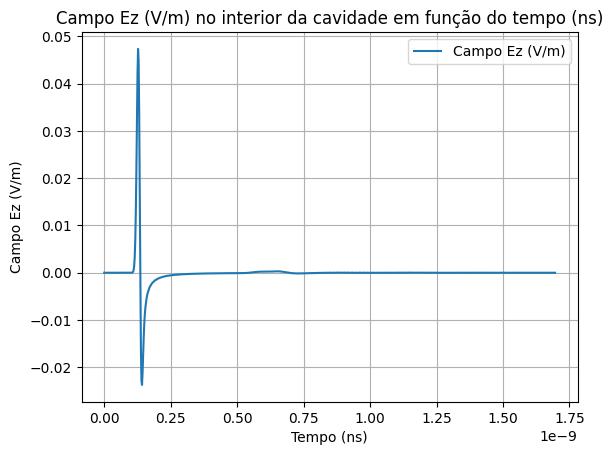

In [61]:
probe_test = UPML(3, Nx // 2 + 10, Ny // 2 + 10)

# plt.plot(grid_t_Ez[Nt//2:-2] * 1e9, probe[Nt//2:], label="Campo Ez (V/m)")
plt.plot(grid_t_Ez[:-1], probe_test[:], label="Campo Ez (V/m)")
plt.title(fr"Campo Ez (V/m) no interior da cavidade em função do tempo (ns)")
plt.xlabel("Tempo (ns)")
plt.ylabel("Campo Ez (V/m)")
plt.grid()
plt.legend()

In [66]:
spread_list = [3, 5, 7, 9]

for s in spread_list:
    probe_test = UPML(s, Nx // 2 + 10, Ny // 2 + 10)
    print(calculate_reflection(probe_test, 0.5e-9))

-43.830262925060346
-37.23367796363026
-33.06147400286763
-30.030070095365986


In [67]:
for s in spread_list:
    probe_test = CPML(s, Nx // 2 + 10, Ny // 2 + 10)
    print(calculate_reflection(probe_test, 0.5e-9))

-50.74792084401915
-44.300978627382634
-40.076325014183126
-37.0863234085184


In [68]:
for s in spread_list:
    probe_test = CPML(s, Nx // 2 + 0, Ny // 2 + 10)
    print(calculate_reflection(probe_test, 0.5e-9))

-54.231308405832046
-48.142011402804826
-43.9307485032281
-40.810035640051


In [69]:
for s in spread_list:
    probe_test = UPML(s, Nx // 2 + 0, Ny // 2 + 10)
    print(calculate_reflection(probe_test, 0.5e-9))

-41.64419612159161
-35.38599723085926
-31.359873819999798
-28.49064333900828


In [70]:
dt

np.float64(2.1227889030003463e-12)

In [79]:
py_list = [0, 2, 5, 10]

for py in py_list:
    probe_test = UPML(3, Nx // 2 + 10, Ny // 2 + py)
    print(calculate_reflection(probe_test, 0.5e-9))

-41.64419612159161
-41.778137974364114
-42.65221254750497
-43.830262925060346
